# Long-context activation-monitoring figures

This notebook renders the confirmatory held-out results and the post-test context controls. Titles are intentionally descriptive rather than result-dependent.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TEST_PATH = Path("artifacts/test_analysis.json")
CONTROL_PATH = Path("artifacts/context_controls.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

test = json.loads(TEST_PATH.read_text(encoding="utf-8"))
control = json.loads(CONTROL_PATH.read_text(encoding="utf-8"))
lengths = np.asarray(sorted(int(value) for value in test["negative_results_by_length"]), dtype=int)
assert lengths.size and set(test["negative_results_by_length"]) == set(test["positive_results_by_length"])
print(f"Loaded {len(lengths)} trajectory lengths: {lengths.tolist()}")

Loaded 4 trajectory lengths: [256, 512, 1024, 2048]


## Figure 1 — Held-out false-positive rate versus trajectory length

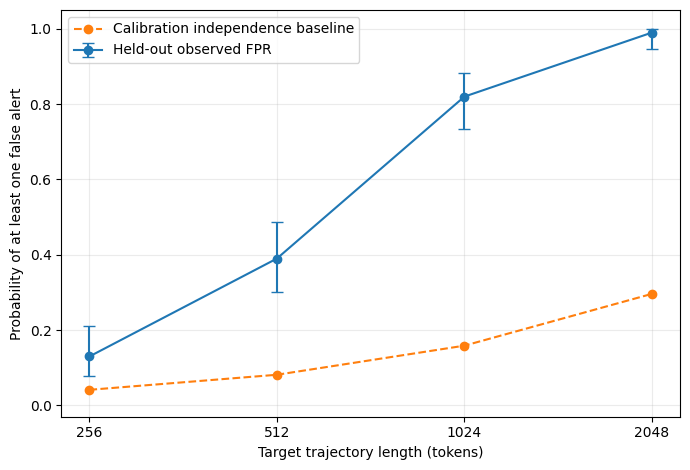

In [2]:
negative = [test["negative_results_by_length"][str(length)] for length in lengths]
rates = np.asarray([item["primary_false_positive_rate"]["rate"] for item in negative])
low = np.asarray([item["primary_false_positive_rate"]["ci95_low"] for item in negative])
high = np.asarray([item["primary_false_positive_rate"]["ci95_high"] for item in negative])
naive = np.asarray([item["naive_independence_predicted_fpr"]["mean"] for item in negative])

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.errorbar(lengths, rates, yerr=np.vstack([rates - low, high - rates]), marker="o", capsize=4, label="Held-out observed FPR")
ax.plot(lengths, naive, marker="o", linestyle="--", label="Calibration independence baseline")
ax.set_xscale("log", base=2)
ax.set_xticks(lengths, [str(length) for length in lengths])
ax.set_ylim(-0.03, 1.05)
ax.set_xlabel("Target trajectory length (tokens)")
ax.set_ylabel("Probability of at least one false alert")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_false_positive_vs_length.png", dpi=250)
plt.show()

## Figure 2 — True-event detection and false alerts elsewhere

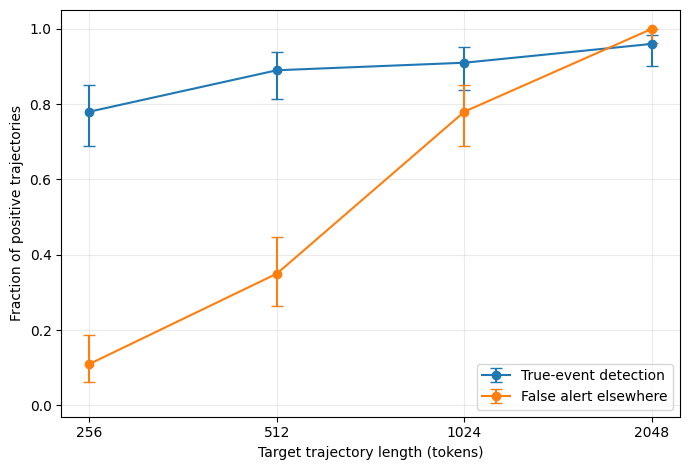

In [3]:
positive = [test["positive_results_by_length"][str(length)] for length in lengths]
detection = np.asarray([item["primary_event_detection_rate"]["rate"] for item in positive])
detection_low = np.asarray([item["primary_event_detection_rate"]["ci95_low"] for item in positive])
detection_high = np.asarray([item["primary_event_detection_rate"]["ci95_high"] for item in positive])
false_alert = np.asarray([item["primary_false_alarm_elsewhere_rate"]["rate"] for item in positive])
false_low = np.asarray([item["primary_false_alarm_elsewhere_rate"]["ci95_low"] for item in positive])
false_high = np.asarray([item["primary_false_alarm_elsewhere_rate"]["ci95_high"] for item in positive])

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.errorbar(lengths, detection, yerr=np.vstack([detection - detection_low, detection_high - detection]), marker="o", capsize=4, label="True-event detection")
ax.errorbar(lengths, false_alert, yerr=np.vstack([false_alert - false_low, false_high - false_alert]), marker="o", capsize=4, label="False alert elsewhere")
ax.set_xscale("log", base=2)
ax.set_xticks(lengths, [str(length) for length in lengths])
ax.set_ylim(-0.03, 1.05)
ax.set_xlabel("Target trajectory length (tokens)")
ax.set_ylabel("Fraction of positive trajectories")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_detection_vs_false_alerts.png", dpi=250)
plt.show()

## Figure 3 — Cumulative false-positive-rate decomposition

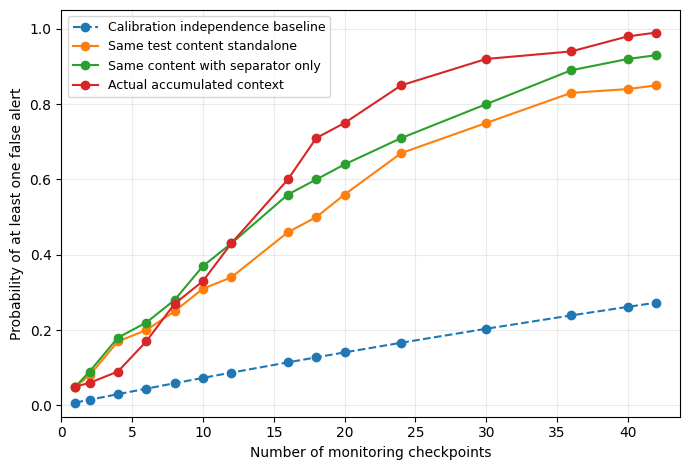

In [4]:
decomposition = control["cumulative_fpr_decomposition"]
checkpoints = np.asarray([item["n_checkpoints"] for item in decomposition])
series = {
    "Calibration independence baseline": [item["naive_calibration_fpr"] for item in decomposition],
    "Same test content standalone": [item["standalone_content_fpr"] for item in decomposition],
    "Same content with separator only": [item["separator_only_fpr"] for item in decomposition],
    "Actual accumulated context": [item["actual_in_context_fpr"] for item in decomposition],
}

fig, ax = plt.subplots(figsize=(7, 4.8))
for label, values in series.items():
    ax.plot(checkpoints, values, marker="o", linestyle="--" if label.startswith("Calibration") else "-", label=label)
ax.set_xlim(0, checkpoints.max() * 1.04)
ax.set_ylim(-0.03, 1.05)
ax.set_xlabel("Number of monitoring checkpoints")
ax.set_ylabel("Probability of at least one false alert")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_fpr_decomposition.png", dpi=250)
plt.show()